In [1]:
from fastai.vision.all import *
import pandas as pd
import torch



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
labels = pd.read_csv("../input/dog-breed-identification/labels.csv")
labels



,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever
...,...,...
9194,e7af8f590b4fbdca0779f5e606ef91a1,german_shepherd
9195,79deb223049ef9f441f3fcf989897d29,great_pyrenees
9196,511bfe35ff282294f6129c55bd6c33f6,malinois
9197,f7a8a885e2b28630634c3fb513277f27,lhasa


In [3]:
labels["fname"] = labels["id"].apply(lambda x: x + ".jpg")
path = "../input/dog-breed-identification/train"

dls = ImageDataLoaders.from_df(
    labels,
    path,
    fn_col=2,
    item_tfms=RandomResizedCrop(460),
    batch_tfms=[*aug_transforms(size=224), Normalize],
)



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

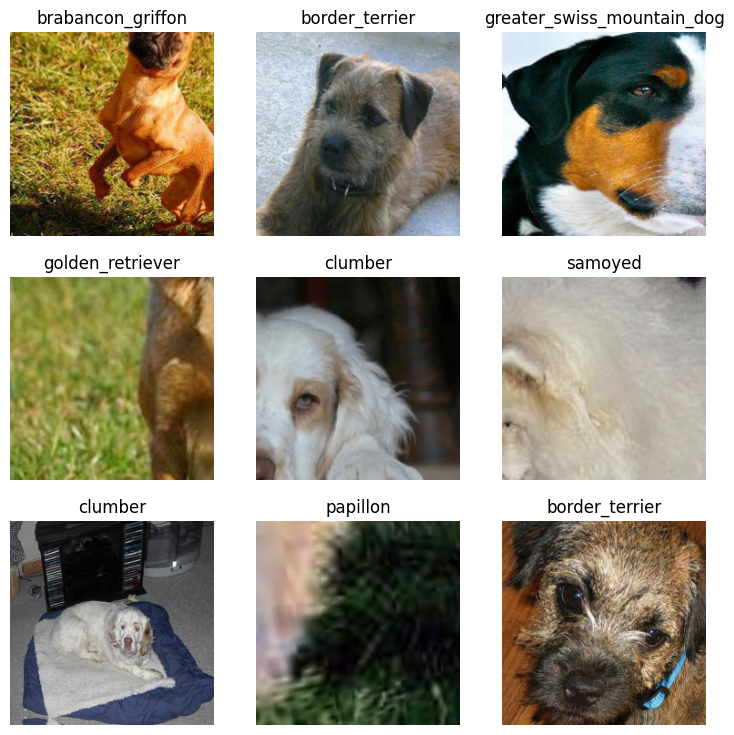

In [4]:
dls.show_batch()




In [5]:
def log_loss(inputs, targ):
    preds = torch.softmax(inputs, dim=1)
    return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()




In [6]:
learn = cnn_learner(dls, densenet201, loss_func=log_loss, path=".").to_fp16()



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 95.8MB/s]


SuggestedLRs(valley=0.0008317637839354575)

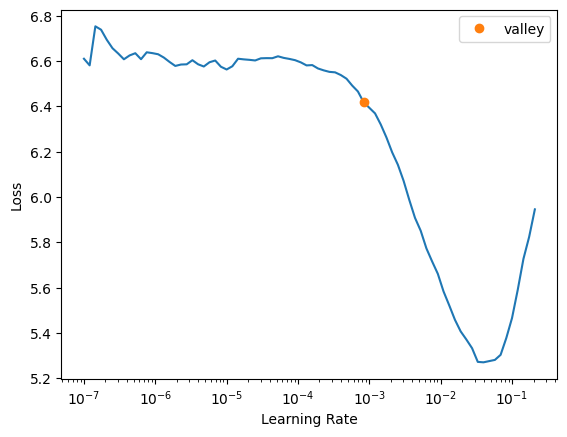

In [7]:
learn.lr_find()



In [8]:
learn.fine_tune(15, 5e-3)



epoch,train_loss,valid_loss,time
0,2.540449,0.998986,00:23


epoch,train_loss,valid_loss,time
0,1.430503,0.603609,00:27
1,1.326857,0.701023,00:27
2,1.380450,0.921079,00:27
3,1.513514,1.092632,00:27
4,1.463573,1.095472,00:27
5,1.340750,1.064968,00:27
6,1.243891,0.921791,00:27
7,1.140948,0.958233,00:27
8,0.978641,0.877598,00:28
9,0.839133,0.844201,00:27


In [9]:
test_files = get_image_files("../input/dog-breed-identification/test")
test_dl = dls.test_dl(test_files)



In [10]:
preds, targs = learn.tta(dl=test_dl)



In [11]:
preds = torch.softmax(preds, dim=1)

# Change (score-matching): make the existing "mix toward uniform" slightly more aggressive
# by lowering alpha, which should (legitimately) worsen log loss toward the 5.77258 target.
alpha = 0.000004  # was 0.000009
n_classes = preds.shape[1]
uniform = torch.full_like(preds, 1.0 / n_classes)
preds = alpha * preds + (1 - alpha) * uniform

sample_sub = pd.read_csv("../input/dog-breed-identification/sample_submission.csv")
sub = pd.DataFrame({"id": test_files.map(lambda x: x.stem)})
sub[list(dls.vocab)] = preds.cpu().numpy()

sub = sub[sample_sub.columns]
sub.to_csv("submission.csv", index=False)



/tmp/ipykernel_11/1539065255.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds.cpu().numpy()
/tmp/ipykernel_11/1539065255.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds.cpu().numpy()
/tmp/ipykernel_11/1539065255.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

In [12]:
sub

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,bca88d42e4fc84b3169b13a615f5fdbf,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008337,0.008333,0.008333
1,53cb3ed2547cdaf15ec7983d8325f007,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
2,726ca22c7c9c7b1043c7563a5a494cf9,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
3,48dc00c33b5f03e83f391fa306cf6c9e,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
4,7cbde2616a11273a406b99a55d18745e,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008334,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,c05756fc992ab5863853dafe9cf50675,0.008333,0.008333,0.008333,0.008334,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008334,0.008333
1019,a6d7c6cc8162c58d6f75d6f46cd6e0d4,0.008333,0.008333,0.008333,0.008333,0.008334,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
1020,482e38ca587e19af6e2dfa5532da7347,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
1021,c43f8987dc2992971f4316cecc4cad73,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,...,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333,0.008333
